In [ ]:
# Number of iterations
K = 10000

# Initialize cumulative results
cumulative_adjusted_priors = np.zeros(par.N)
cumulative_new_real_util = np.zeros(par.N)
cumulative_new_chosen_career = np.zeros(par.J)
cumulative_switch_decisions = 0

for _ in range(K):
    adjusted_priors, new_chosen_career, new_real_util, x = career.prior_expec()
    expected_utilities_of_chosen_career = adjusted_priors[np.arange(adjusted_priors.shape[0]), new_chosen_career]
    cumulative_adjusted_priors += expected_utilities_of_chosen_career
    cumulative_new_real_util += new_real_util
    
    for i in range(par.J):
        cumulative_new_chosen_career[i] += np.sum(new_chosen_career == i)
    
    
# Calculate averages
average_adjusted_priors = cumulative_adjusted_priors / K
average_new_real_util = cumulative_new_real_util / K
share_new_chosen_career = cumulative_new_chosen_career / (par.N * K)
share_switch_decisions = cumulative_switch_decisions / (par.N * K)

# Print results
print("Average adjusted priors:\n", average_adjusted_priors)
print("Average new realized utilities:\n", average_new_real_util)
print("Share of new chosen careers:\n", share_new_chosen_career)
print("Share of switch decisions:\n", share_switch_decisions)

AttributeError: 'types.SimpleNamespace' object has no attribute 'N'

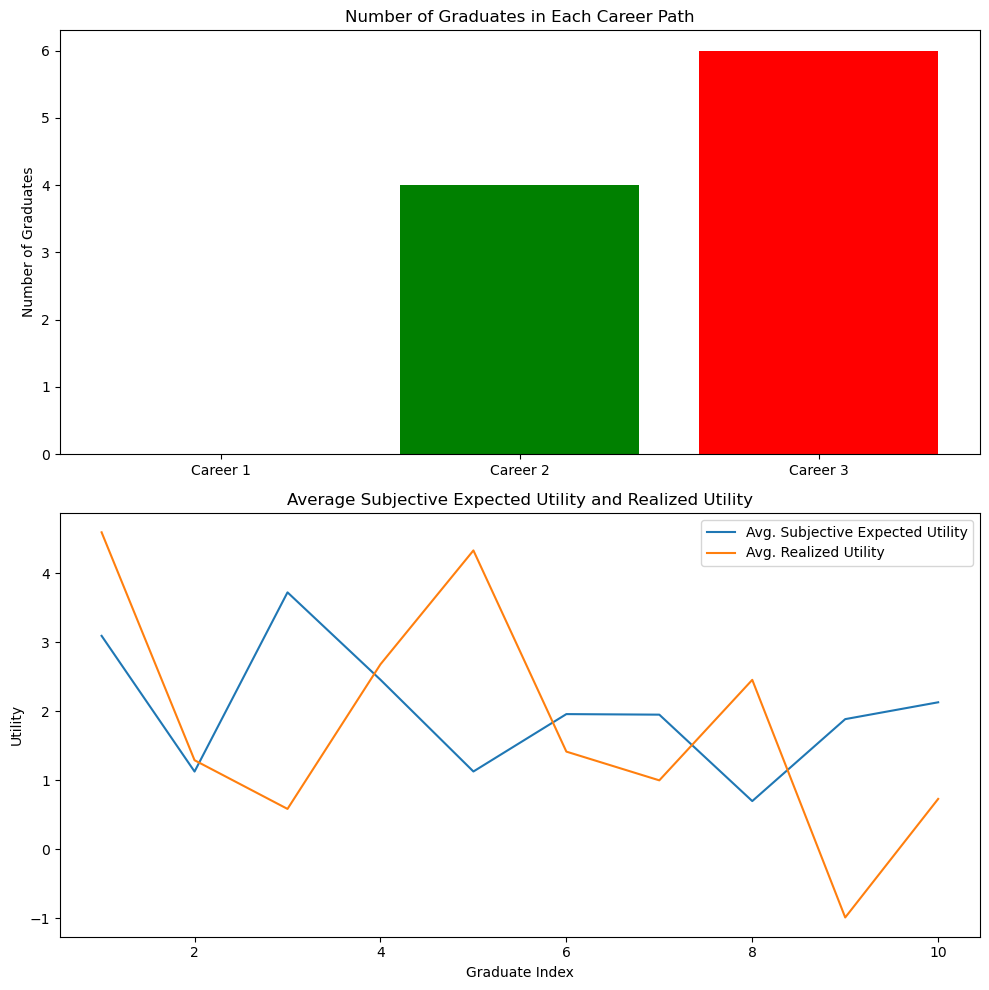

In [ ]:
# Write your answer here 

par.i = np.array([1,2,3,4,5,6,7,8,9,10])


# Simulate prior expected utility, chosen careers, and realized utilities based on friends' information
prior_expec_util, chosen_career, real_util, eps_self = career.prior_expec()

career.visualize_results(chosen_career, np.mean(prior_expec_util, axis=1), real_util)


spørgsmål 3     

In [ ]:
# Number of iterations
K = 10000

# Initialize cumulative results
cumulative_adjusted_priors = np.zeros((par.N, par.J))
cumulative_new_real_util = np.zeros(par.N)
cumulative_new_chosen_career = np.zeros(par.J)
cumulative_switch_decisions = 0

for _ in range(K):
    new_chosen_career, switch_decisions, adjusted_priors, new_real_util = career.career_switching()
    
    cumulative_adjusted_priors += adjusted_priors
    cumulative_new_real_util += new_real_util
    
    for i in range(par.J):
        cumulative_new_chosen_career[i] += np.sum(new_chosen_career == i)
    
    cumulative_switch_decisions += np.sum(switch_decisions)

# Calculate averages
average_adjusted_priors = cumulative_adjusted_priors / K
average_new_real_util = cumulative_new_real_util / K
share_new_chosen_career = cumulative_new_chosen_career / (par.N * K)
share_switch_decisions = cumulative_switch_decisions / (par.N * K)

# Print results
print("Average adjusted priors:\n", average_adjusted_priors)
print("Average new realized utilities:\n", average_new_real_util)
print("Share of new chosen careers:\n", share_new_chosen_career)
print("Share of switch decisions:\n", share_switch_decisions)

Average adjusted priors:
 [[-2.23128868e-01  7.58580974e-01  1.93599101e+00]
 [-8.80379321e-02  9.15903604e-01  2.21994227e+00]
 [-1.83884889e-02  9.79048946e-01  2.38172363e+00]
 [-3.04611895e-02  9.99591159e-01  2.46695412e+00]
 [-2.09299243e-02  1.02192310e+00  2.57242951e+00]
 [-1.46446895e-02  1.02312142e+00  2.66974868e+00]
 [-1.17882441e-02  1.02009699e+00  2.64412439e+00]
 [-1.51998979e-02  1.03081486e+00  2.72382697e+00]
 [-2.14685916e-03  1.02655220e+00  2.72598469e+00]
 [-1.02813870e-02  1.03399268e+00  2.74260803e+00]]
Average new realized utilities:
 [2.96396724 3.06263173 3.1310134  3.13512354 3.19594912 3.2350738
 3.20599968 3.2398895  3.23361662 3.24760525]
Share of new chosen careers:
 [0.05752 0.23698 0.7055 ]
Share of switch decisions:
 0.22085


In [ ]:
# Old class shit

    def prior_expec(self, seed=None):
        par = self.par

        if seed is not None:
            np.random.seed(seed)
        
        eps_self = np.zeros((par.N, par.J))
        prior_expec_util = np.zeros((par.N, par.J))
        choose_career = np.zeros(par.N, dtype=int)
        real_util = np.zeros(par.N)
        friends_noise = np.zeros(par.J)
        
        for i in range(par.N):
            friends_noise = np.random.normal(0, par.sigma, par.J * (i + 1))
            eps_self[i] = np.random.normal(0, par.sigma, par.J)

            for j in range(par.J):
                prior_expec_util[i, j] = par.v[j] + np.mean(np.random.normal(0, par.sigma, i+1))
            
            choose_career[i] = np.argmax(prior_expec_util[i])
            real_util[i] = par.v[choose_career[i]] + eps_self[i, choose_career[i]]

        return prior_expec_util, choose_career, real_util, eps_self
    
    def visualize_results(self, choices, avg_subjective_utilities, avg_realized_utilities):
        fig, axs = plt.subplots(2, 1, figsize=(10, 10))

        career_counts = np.bincount(choices)

        career_labels = ['Career 1', 'Career 2', 'Career 3']

        axs[0].bar(career_labels, career_counts, color=['skyblue', 'green', 'red'])
        axs[0].set_ylabel('Number of Graduates')
        axs[0].set_title('Number of Graduates in Each Career Path')

        # Average subjective expected utility and realized utility
        axs[1].plot(range(1, self.par.N + 1), avg_subjective_utilities, label='Avg. Subjective Expected Utility')
        axs[1].plot(range(1, self.par.N + 1), avg_realized_utilities, label='Avg. Realized Utility')
        axs[1].set_title('Average Subjective Expected Utility and Realized Utility')
        axs[1].set_xlabel('Graduate Index')
        axs[1].set_ylabel('Utility')
        axs[1].legend()

        plt.tight_layout()
        plt.show()
    
    def career_switching(self, seed=None):
        par = self.par
        if seed is not None:
            np.random.seed(seed)
        new_chosen_career = np.zeros(par.N, dtype=int)
        new_real_util = np.zeros(par.N)
        switch_decisions = np.zeros(par.N)
        adjusted_priors = np.zeros((par.N, par.J))

        prior_expec_util, choose_career, real_util, eps_self = self.prior_expec()
        for i in range(par.N):
            initial_career = choose_career[i]
            initial_realized_utility = real_util[i]
            for j in range(par.J):
                initial_expected_utility = prior_expec_util[i, j]
                if j != initial_career:
                    adjusted_priors[i, j] = initial_expected_utility - par.c
                else:
                    adjusted_priors[i, j] = initial_realized_utility

            # Choose the career with the highest expected utility
            new_chosen_career[i] = np.argmax(adjusted_priors[i])
            new_real_util[i] = par.v[new_chosen_career[i]] + eps_self[i, new_chosen_career[i]]
            # Record if the graduate decided to switch careers
            switch_decisions[i] = 1 if new_chosen_career[i] != initial_career else 0
    
        return new_chosen_career, switch_decisions, adjusted_priors, new_real_util